In [19]:
import pandas as pd
import plotly.express as px
import numpy as np
import os

# Set a random seed so the dummy data is the same every time
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [20]:
# 1. Generate Date Range (Daily data for 3 months)
dates = pd.date_range(start='2024-01-01', end='2024-03-30', freq='D')

# 2. Create fake coordinates (centered roughly on US)
# We will generate 500 fake sales events
n_samples = 500
random_lats = np.random.uniform(30, 45, n_samples) # Roughly US Latitudes
random_lons = np.random.uniform(-120, -75, n_samples) # Roughly US Longitudes

# 3. Create DataFrame
df = pd.DataFrame({
    'date_column': np.random.choice(dates, n_samples),
    'latitude': random_lats,
    'longitude': random_lons,
    'sales_amount': np.random.randint(50, 500, n_samples) # Sales between $50 and $500
})

# 4. Sort by date (Crucial for animation!)
df = df.sort_values('date_column')

# Preview
print(f"Created dummy dataset with {len(df)} rows.")
df.head()

Created dummy dataset with 500 rows.


,date_column,latitude,longitude,sales_amount
325,2024-01-01,41.068454,-78.606497,446
373,2024-01-02,40.245102,-101.606962,68
305,2024-01-02,44.637781,-86.860009,205
235,2024-01-02,40.836782,-80.525976,248
411,2024-01-02,44.250930,-107.937136,372


In [21]:
# 1. Convert to datetime if not already
df['timestamp'] = pd.to_datetime(df['date_column'])

# 2. Create a "Period" column (e.g., Weekly 'W' or Monthly 'M')
# This text column will be the slider at the bottom of the map
df['Animation_Frame'] = df['timestamp'].dt.to_period('W').astype(str)

# 3. Aggregate!
# We group by the Time Period and the Location.
# Note: In real data, you might round lat/long to 2-3 decimal places to 'cluster' nearby dots.
df['lat_round'] = df['latitude'].round(2)
df['lon_round'] = df['longitude'].round(2)

grouped_df = df.groupby(['Animation_Frame', 'lat_round', 'lon_round']).agg({
    'sales_amount': 'sum'
}).reset_index()

# Sort again just to be safe
grouped_df = grouped_df.sort_values('Animation_Frame')

print("Data aggregated by Week!")
grouped_df.head()

Data aggregated by Week!


,Animation_Frame,lat_round,lon_round,sales_amount
0,2024-01-01/2024-01-07,31.41,-117.01,446
21,2024-01-01/2024-01-07,41.07,-78.61,446
22,2024-01-01/2024-01-07,41.30,-79.50,54
23,2024-01-01/2024-01-07,41.42,-82.43,278
24,2024-01-01/2024-01-07,41.55,-78.05,324


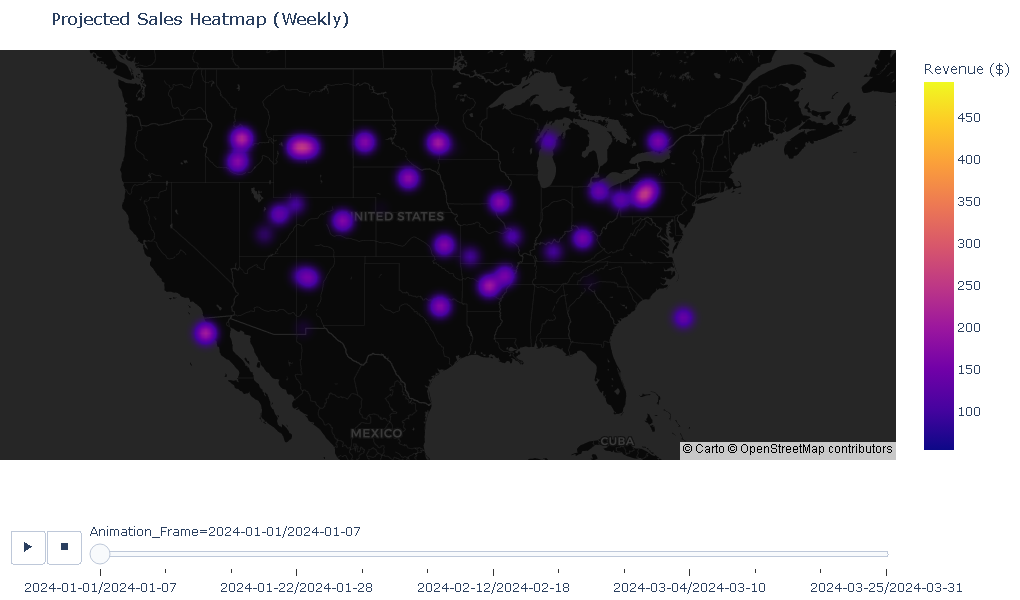

In [23]:
# Create the figure
fig = px.density_mapbox(
    grouped_df,
    lat='lat_round',
    lon='lon_round',
    z='sales_amount',          # Heat intensity based on revenue
    radius=20,                 # How "spread out" the heat blobs are
    center=dict(lat=37.09, lon=-95.71), # Center of USA
    zoom=3,
    mapbox_style="carto-darkmatter", # Dark theme matches the 'cool' look
    animation_frame="Animation_Frame", # This creates the Play button
    title="Projected Sales Heatmap (Weekly)",
    height=600
)

# Cosmetic Polish
fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Revenue ($)")
)

# Show inside Jupyter
fig.show()

In [25]:
import os

# The 'r' before the quote prevents Python from getting confused by the backslashes
save_folder = r"C:\Users\Clay_\OneDrive\Gordon GIS\gis_animation"

# Combine folder and filename
output_file = os.path.join(save_folder, "Sales_Heatmap.html")

# Write the file
fig.write_html(output_file)

print(f"Success! Map saved to: {output_file}")

Success! Map saved to: C:\Users\Clay_\OneDrive\Gordon GIS\gis_animation\Sales_Heatmap.html


In [26]:
# 1. Create a "City" name for our dummy data
# (In the real client data, you would just use their 'City' column)
# We will just make up names based on the coordinates for this demo
conditions = [
    (df['latitude'] > 40) & (df['longitude'] < -100),
    (df['latitude'] <= 40) & (df['longitude'] < -100),
    (df['latitude'] > 40) & (df['longitude'] >= -100),
    (df['latitude'] <= 40) & (df['longitude'] >= -100)
]
choices = ['Northwest Hub', 'Southwest Branch', 'Northeast HQ', 'Southeast Depot']
df['Region'] = np.select(conditions, choices, default='Central Office')

# 2. Group by Week and Region
bar_df = df.groupby(['Animation_Frame', 'Region']).agg({
    'sales_amount': 'sum'
}).reset_index()

# 3. Calculate "Cumulative" Sales (Running Total)
# This makes the bars grow over time, which looks satisfying
bar_df['Cumulative_Sales'] = bar_df.groupby('Region')['sales_amount'].cumsum()

# Sort for the animation order
bar_df = bar_df.sort_values(['Animation_Frame', 'Cumulative_Sales'], ascending=[True, True])

print("Bar chart data ready!")
bar_df.head()

Bar chart data ready!


,Animation_Frame,Region,sales_amount,Cumulative_Sales
3,2024-01-01/2024-01-07,Southwest Branch,1699,1699
1,2024-01-01/2024-01-07,Northwest Hub,2337,2337
2,2024-01-01/2024-01-07,Southeast Depot,2661,2661
0,2024-01-01/2024-01-07,Northeast HQ,3253,3253
5,2024-01-08/2024-01-14,Northwest Hub,1708,4045


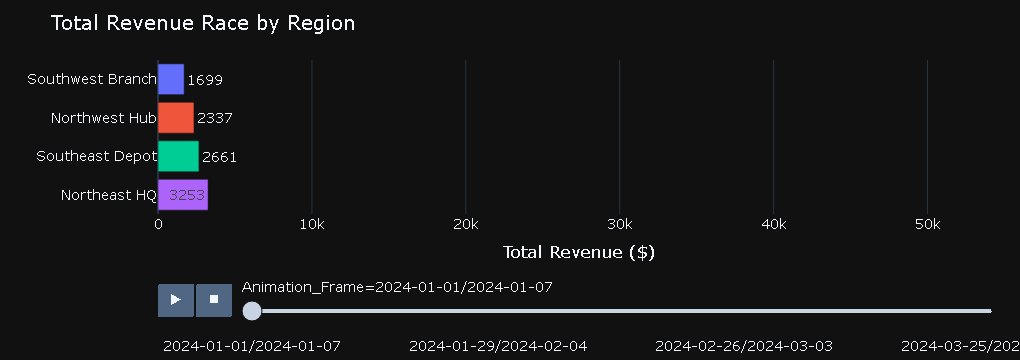

In [27]:
# Create the Bar Chart
fig_bar = px.bar(
    bar_df, 
    x="Cumulative_Sales", 
    y="Region", 
    color="Region",
    orientation='h', # Horizontal bars look better for "races"
    text="Cumulative_Sales", 
    animation_frame="Animation_Frame",
    range_x=[0, bar_df['Cumulative_Sales'].max() * 1.1], # Fix the x-axis scale so it doesn't jump
    title="Total Revenue Race by Region",
    template="plotly_dark" # Match the dark map theme
)

# Polish the look
fig_bar.update_layout(
    xaxis_title="Total Revenue ($)",
    yaxis_title="",
    showlegend=False,
    margin={"r":20,"t":60,"l":0,"b":0},
    font=dict(size=14)
)

# Show the chart
fig_bar.show()

In [28]:
import os

# 1. Define the HTML content as a string
dashboard_html = """
<!DOCTYPE html>
<html>
<head>
    <title>Sales Dashboard</title>
    <style>
        body { background-color: #111; color: white; font-family: sans-serif; }
        .container { display: flex; flex-wrap: wrap; }
        .box { flex: 1; min-width: 400px; padding: 10px; }
        iframe { width: 100%; height: 500px; border: none; }
    </style>
</head>
<body>
    <h1>Sales Performance Dashboard</h1>
    <div class="container">
        <div class="box">
            <h3>Geographic Heatmap</h3>
            <iframe src="Sales_Heatmap.html"></iframe>
        </div>
        <div class="box">
            <h3>Regional Performance</h3>
            <iframe src="Sales_Chart.html"></iframe>
        </div>
    </div>
</body>
</html>
"""

# 2. Use your existing save_folder path
# (Ensure you ran the cell defining 'save_folder' previously)
# If you restarted the kernel, uncomment the line below:
# save_folder = r"C:\Users\Clay_\OneDrive\Gordon GIS\gis_animation"

file_path = os.path.join(save_folder, "dashboard.html")

# 3. Write the file
with open(file_path, "w") as f:
    f.write(dashboard_html)

print(f"Dashboard created at: {file_path}")

Dashboard created at: C:\Users\Clay_\OneDrive\Gordon GIS\gis_animation\dashboard.html


In [29]:
import os

# 1. Ensure you are pointing to the right folder
save_folder = r"C:\Users\Clay_\OneDrive\Gordon GIS\gis_animation"

# 2. Define the path for the missing chart file
chart_file = os.path.join(save_folder, "Sales_Chart.html")

# 3. Save the bar chart (Ensure your chart variable is named 'fig_bar')
# If you get an error saying 'fig_bar' is not defined, you need to re-run the cell where you created the bar chart first.
fig_bar.write_html(chart_file)

print(f"Success! Bar chart saved to: {chart_file}")

Success! Bar chart saved to: C:\Users\Clay_\OneDrive\Gordon GIS\gis_animation\Sales_Chart.html
